In [41]:
import cv2
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np


In [42]:
ct_img = cv2.imread('data/synthetic_slices/Patient_001/CT/slice_001.png', cv2.IMREAD_GRAYSCALE)
mri_img = cv2.imread('data/synthetic_slices/Patient_001/MRI/slice_001.png', cv2.IMREAD_GRAYSCALE)

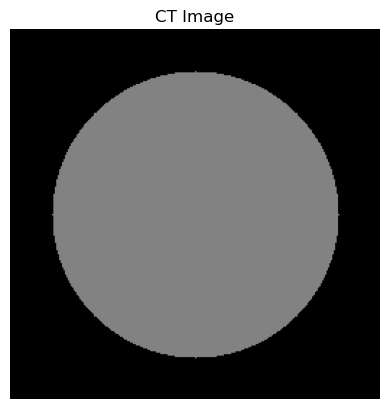

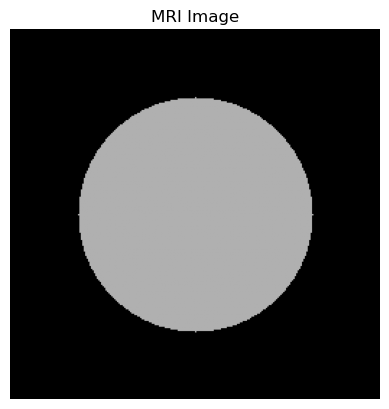

In [43]:
plt.imshow(ct_img, cmap='gray', vmin=0, vmax=255)
plt.title('CT Image')
plt.axis('off')
plt.show()

plt.imshow(mri_img, cmap='gray', vmin=0, vmax=255)
plt.title('MRI Image')
plt.axis('off')
plt.show()

In [44]:
equalized_ct = cv2.equalizeHist(ct_img)   
equalized_mri = cv2.equalizeHist(mri_img)   


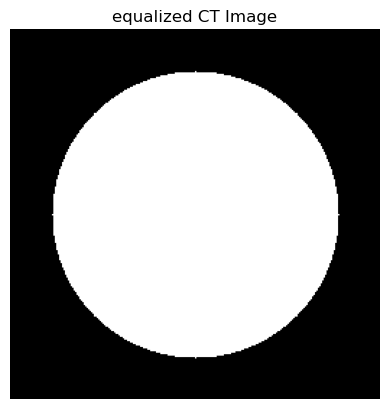

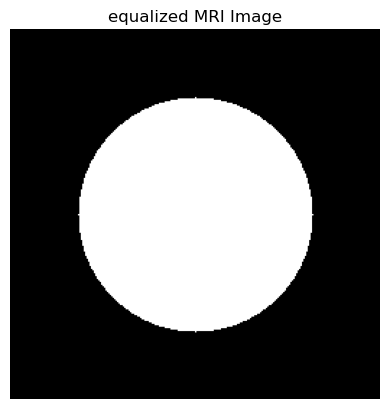

In [45]:
plt.imshow(equalized_ct, cmap='gray')
plt.title('equalized CT Image')
plt.axis('off')
plt.show()

plt.imshow(equalized_mri, cmap='gray')
plt.title('equalized MRI Image')
plt.axis('off')
plt.show()

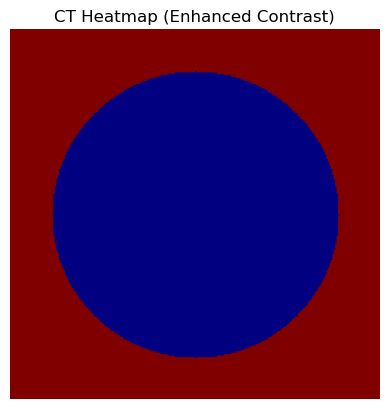

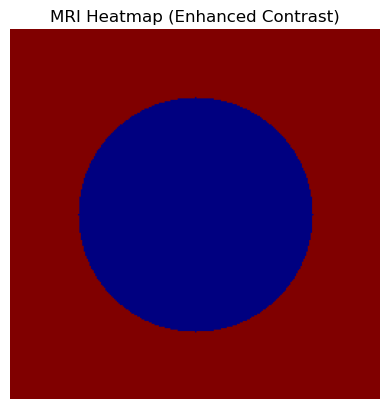

In [46]:
heatmap_ct = cv2.applyColorMap(equalized_ct, cv2.COLORMAP_JET) #color mapping
plt.imshow(heatmap_ct)
plt.title('CT Heatmap (Enhanced Contrast)')
plt.axis('off')
plt.show()

heatmap_mri = cv2.applyColorMap(equalized_mri, cv2.COLORMAP_JET) #color mapping
plt.imshow(heatmap_mri)
plt.title('MRI Heatmap (Enhanced Contrast)')
plt.axis('off')
plt.show()


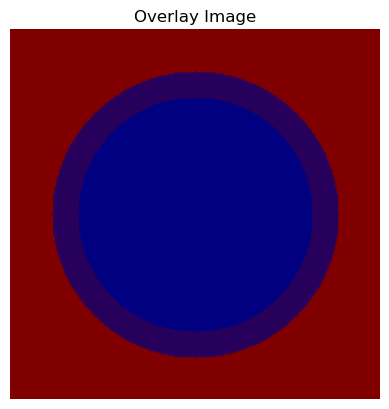

In [47]:
# Both images must be the exact same size 
target_height, target_width = heatmap_ct.shape[:2]
mri_resized = cv2.resize(heatmap_mri, (target_width, target_height))      # dsize = (width, height)

overlay_img = cv2.addWeighted(mri_resized, 0.3, heatmap_ct, 0.7, 0)

plt.imshow(overlay_img, cmap='gray')
plt.title('Overlay Image')
plt.axis('off')
plt.show()


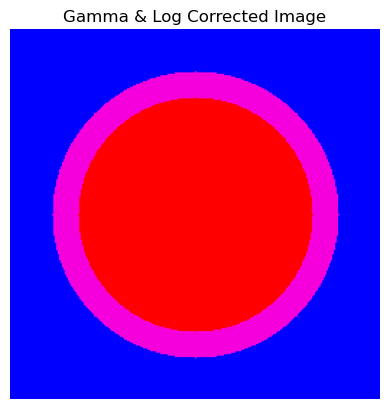

In [50]:
overlay_log = np.log1p(overlay_img.astype(np.float32))
overlay_log = cv2.normalize(overlay_log, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

gamma = 0.5
normalized_img = overlay_log.astype(np.float32) / 255.0
overlay_log_gamma = np.power(normalized_img, gamma)
overlay_log_gamma = (overlay_log_gamma * 255).astype(np.uint8)

overlay_rgb = cv2.cvtColor(overlay_log_gamma, cv2.COLOR_BGR2RGB)

plt.imshow(overlay_rgb, cmap='gray')
plt.title(f'Gamma & Log Corrected Image')
plt.axis('off')
plt.show()

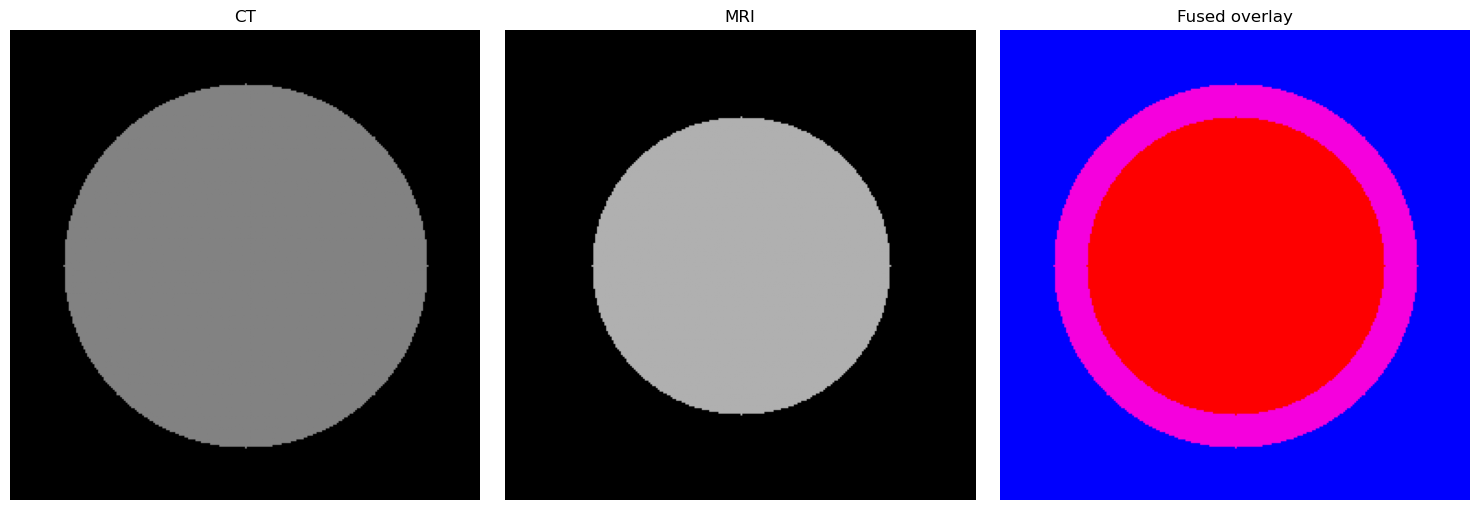

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['CT', 'MRI', 'Fused overlay']
for ax, img, title in zip(axes, [ct_img, mri_img, overlay_rgb], titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()